In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import re
import string
import warnings

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# Load Dataset

df = pd.read_csv("dataset/Phishing_Email.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nEmail Type Distribution:")
print(df["Email Type"].value_counts())

Shape of Dataset: (18650, 3)

Column Names:
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')

Missing Values:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

Email Type Distribution:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


In [4]:
# Data Cleaning

# Remove unnecessary column
df.drop("Unnamed: 0", axis=1, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Check dataset after cleaning
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# Display first 5 rows
df.head()

Dataset Shape: (18634, 2)

Missing Values:
Email Text    0
Email Type    0
dtype: int64


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
# Text Preprocessing Function

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()                           # Convert to lowercase
    text = re.sub(r'http\S+|www\S+', '', text)    # Remove URLs
    text = re.sub(r'<.*?>', '', text)             # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # Remove punctuation & numbers
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# Apply preprocessing
df["Clean_Text"] = df["Email Text"].apply(preprocess_text)

# Display original and cleaned text
df[["Email Text", "Clean_Text"]].head()

,Email Text,Clean_Text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term name im...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still available assist ro...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low price lower drapery se...


In [6]:
# Convert Labels to Numerical Values

df["Label"] = df["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

# Check the labels
df[["Email Type", "Label"]].head()

,Email Type,Label
0,Safe Email,0
1,Safe Email,0
2,Safe Email,0
3,Phishing Email,1
4,Phishing Email,1


In [7]:
# TF-IDF Feature Extraction

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"]).toarray()
y = df["Label"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (18634, 5000)
Target Shape: (18634,)


In [8]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (14907, 5000)
Testing Data Shape: (3727, 5000)


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [10]:
# Naive Bayes Model

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9546552186745372
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2209
           1       0.94      0.95      0.94      1518

    accuracy                           0.95      3727
   macro avg       0.95      0.95      0.95      3727
weighted avg       0.95      0.95      0.95      3727



In [11]:
# Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9635095250872016
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2209
           1       0.95      0.96      0.96      1518

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



In [12]:
# Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9624362758250604
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2209
           1       0.94      0.97      0.95      1518

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



In [13]:
# Neural Network Model

mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)

mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)

print("Neural Network Accuracy:", accuracy_score(y_test, mlp_pred))
print(classification_report(y_test, mlp_pred))

Neural Network Accuracy: 0.9680708344513013
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2209
           1       0.94      0.98      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727



In [14]:
# Compare Model Performance

model_names = [
    "Naive Bayes",
    "Logistic Regression",
    "Random Forest",
    "Neural Network"
]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, mlp_pred)
]

comparison = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
3,Neural Network,0.968071
1,Logistic Regression,0.963510
2,Random Forest,0.962436
0,Naive Bayes,0.954655


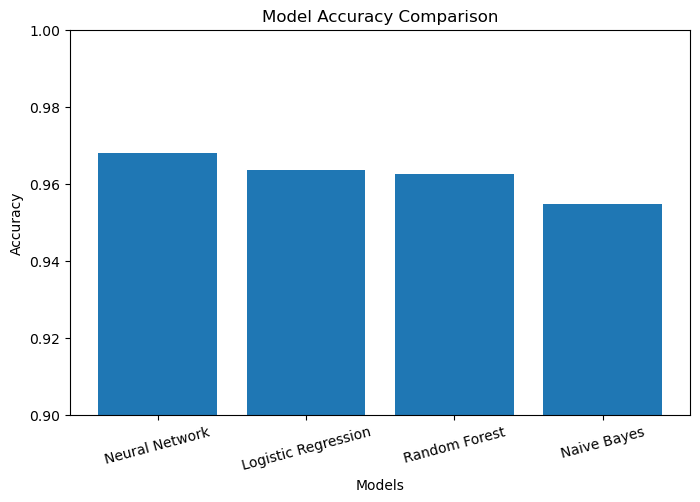

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.xticks(rotation=15)
plt.savefig("model_comparison.png",dpi=300, bbox_inches="tight")

plt.show()

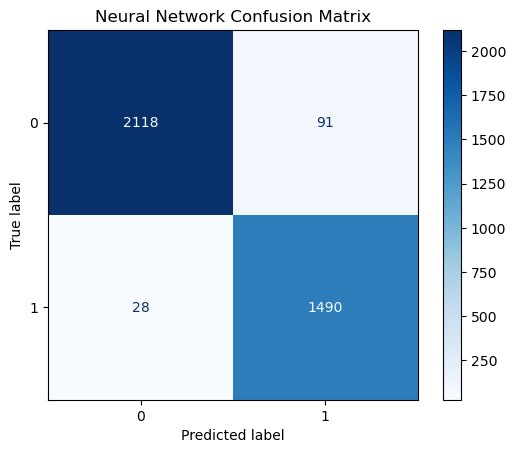

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, mlp_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Neural Network Confusion Matrix")
plt.show()

In [17]:
import joblib

# Save the best model
joblib.dump(mlp_model, "model/phishing_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "model/tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [18]:
import streamlit as st
import joblib
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load model and vectorizer
model = joblib.load("model/phishing_model.pkl")
vectorizer = joblib.load("model/tfidf_vectorizer.pkl")

# Download NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Text preprocessing function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

# Streamlit UI
st.title("📧 AI-Driven Phishing Email Detection")
st.write("Enter an email below to check whether it is Safe or Phishing.")

email = st.text_area("Email Text")

if st.button("Predict"):

    if email.strip() == "":
        st.warning("Please enter an email.")
    else:
        cleaned = clean_text(email)
        vector = vectorizer.transform([cleaned])
        prediction = model.predict(vector)

        if prediction[0] == 1:
            st.error("🚨 Phishing Email")
        else:
            st.success("✅ Safe Email")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-07-25 19:18:49.119 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-25 19:18:52.175 
  command:

    streamlit run C:\Users\Admin\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-25 19:18:52.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-25 19:18:52.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-25 19:18:52.178 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni